In [12]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics
import subprocess
import sys
import seaborn as sns
import numpy as np
from scipy.sparse import csr_matrix
import scanpy.external as sce
from sklearn.metrics import silhouette_score
import datetime

# sys.path.append('../utils')
# from functions import * 

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

sns.set(style="whitegrid")

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis
scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.14.1 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.2 igraph==0.11.5 louvain==0.8.2 pynndescent==0.5.12


In [2]:
# load in tabula sapien data 
ts_adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/CZI/tabula-sapiens/TS_figshare/TabulaSapiens.h5ad")

# load in allen brain data 
ab_adata = sc.read_h5ad("/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/adata_2025-01-07_HVG_only_False.h5ad")

In [3]:
# add source to each adata file 
ts_adata.obs["source"] = "tabula_sapiens"
ab_adata.obs["source"] = "allen_brain"

In [4]:
# subset ts_adata to only cells from method=="smartseq2"
ts_adata = ts_adata[ts_adata.obs["method"]=="smartseq2"].copy()

# let's keep just the non-neuronal cells from ab_data 
ab_adata = ab_adata[ab_adata.obs["class_label"] == "Non-neuronal"].copy()

# rename ab_adata "gene_name" to "gene_symbol" and assess how many genes are in common between the two datasets
ab_adata.var.rename(columns={"gene_name":"gene_symbol"}, inplace=True)
print("Number of genes in common between the two datasets:", len(set(ts_adata.var["gene_symbol"]).intersection(set(ab_adata.var["gene_symbol"]))))

Number of genes in common between the two datasets: 28230


In [5]:
adata1 = ab_adata.copy()
adata2 = ts_adata.copy()

# Step 1: Align genes between the two datasets
common_genes = adata1.var["gene_symbol"].isin(adata2.var["gene_symbol"])
adata1 = adata1[:, common_genes]

common_genes = adata2.var["gene_symbol"].isin(adata1.var["gene_symbol"])
adata2 = adata2[:, common_genes]

# Ensure the genes are in the same order
adata2 = adata2[:, adata1.var_names]

# Step 2: Use raw counts from the respective layers
adata1_raw = adata1.layers["counts"]
adata2_raw = adata2.layers["raw_counts"]

# Step 3: Normalize raw counts
adata1.layers["normalized_raw"] = adata1_raw.copy() 
adata2.layers["normalized_raw"] = adata2_raw.copy()

sc.pp.normalize_total(adata1, layer="normalized_raw", target_sum=1e4)
sc.pp.log1p(adata1, layer="normalized_raw")

sc.pp.normalize_total(adata2, layer="normalized_raw", target_sum=1e4)
sc.pp.log1p(adata2, layer="normalized_raw")

# Replace .X with normalized raw counts
adata1.X = csr_matrix(adata1.layers["normalized_raw"])  # Ensure sparse matrix
adata2.X = csr_matrix(adata2.layers["normalized_raw"])  # Ensure sparse matrix

# Step 3: Combine datasets
adata1.obs["dataset"] = "AllenBrain"
adata2.obs["dataset"] = "TabulaSapien"

combined = adata1.concatenate(adata2, batch_key="dataset")
# need to add shared column in combined.obs for cell type... 
combined.obs["cell_type_combined"] = adata1.obs["subclass_label"].tolist() + adata2.obs["cell_ontology_class"].tolist()

/scratch/ipykernel_4951/3354836304.py:19: ImplicitModificationWarning: Setting element `.layers['normalized_raw']` of view, initializing view as actual.
  adata1.layers["normalized_raw"] = adata1_raw.copy()
/scratch/ipykernel_4951/3354836304.py:20: ImplicitModificationWarning: Setting element `.layers['normalized_raw']` of view, initializing view as actual.
  adata2.layers["normalized_raw"] = adata2_raw.copy()


normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


/scratch/ipykernel_4951/3354836304.py:36: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata1.concatenate(adata2, batch_key="dataset")
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/merge.py:1357: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [6]:
# get most variable genes 
sc.pp.highly_variable_genes(combined, n_top_genes=5000, flavor="seurat_v3", batch_key="dataset")

extracting highly variable genes


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:72: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [7]:
# Step 4: Perform PCA and UMAP
sc.pp.pca(combined)
sc.pp.neighbors(combined)
sc.tl.umap(combined)

computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:40)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:47)


In [8]:
combined.shape

(31804, 28230)

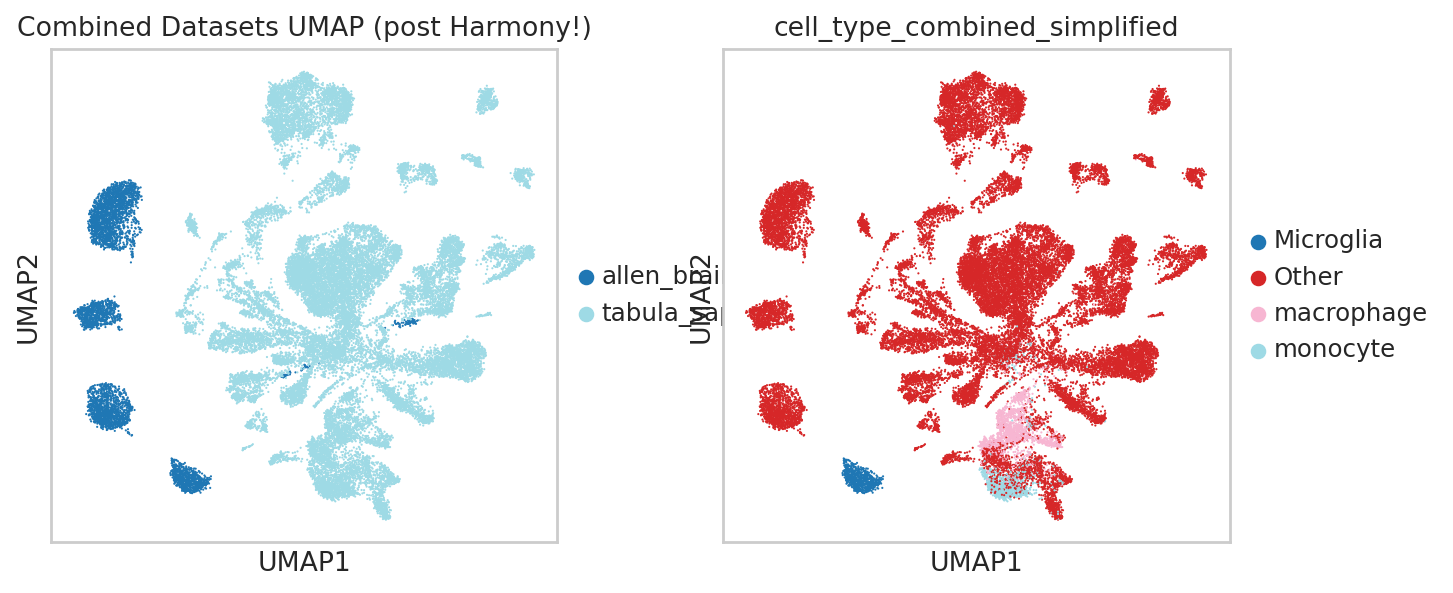

In [9]:
# I want to only color Microglia and Macrophage cells and monocyte 
cells_color = ["Microglia", "macrophage", "monocyte"]

combined.obs["cell_type_combined_simplified"] = combined.obs["cell_type_combined"].apply(
    lambda x: x if x in cells_color else "Other"
)

# Convert the new column to a categorical dtype
combined.obs["cell_type_combined_simplified"] = combined.obs["cell_type_combined_simplified"].astype("category")
# Visualize with UMAP
sc.pl.umap(
    combined, 
    color=["source", "cell_type_combined_simplified"], palette="tab20",
    title="Combined Datasets UMAP (post Harmony!)",
)


In [41]:
combined.obs.source.value_counts()

source
tabula_sapiens    27051
allen_brain        4753
Name: count, dtype: int64

In [10]:
combined.obs.subclass_label.value_counts()

subclass_label
Oligodendrocyte    1930
Astrocyte          1187
OPC                 773
Microglia           750
Endothelial          70
Pericyte             32
VLMC                 11
Name: count, dtype: int64

In [13]:
silhouette_batch = silhouette_score(combined.obsm["X_umap"], combined.obs["dataset"])
silhouette_biology = silhouette_score(combined.obsm["X_umap"], combined.obs["cell_type_combined_simplified"])
print(f"Silhouette Score by Batch: {silhouette_batch}")
print(f"Silhouette Score by Cell Type: {silhouette_biology}")

Silhouette Score by Batch: 0.36801406741142273
Silhouette Score by Cell Type: 0.009136592969298363


In [14]:
sce.pp.harmony_integrate(combined, 'source')
# Check that Harmony has updated the PCA representation
print("Keys in obsm after Harmony:", combined.obsm.keys())

2025-01-08 16:44:15,673 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-08 16:44:23,551 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-08 16:44:23,990 - harmonypy - INFO - Iteration 1 of 10
2025-01-08 16:44:36,775 - harmonypy - INFO - Iteration 2 of 10
2025-01-08 16:44:48,049 - harmonypy - INFO - Converged after 2 iterations


Keys in obsm after Harmony: KeysView(AxisArrays with keys: X_pca, X_umap, X_pca_harmony)


In [15]:
# Compute neighbors and UMAP using the Harmony-corrected PCA
sc.pp.neighbors(combined, use_rep="X_pca_harmony")
sc.tl.umap(combined)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:47)


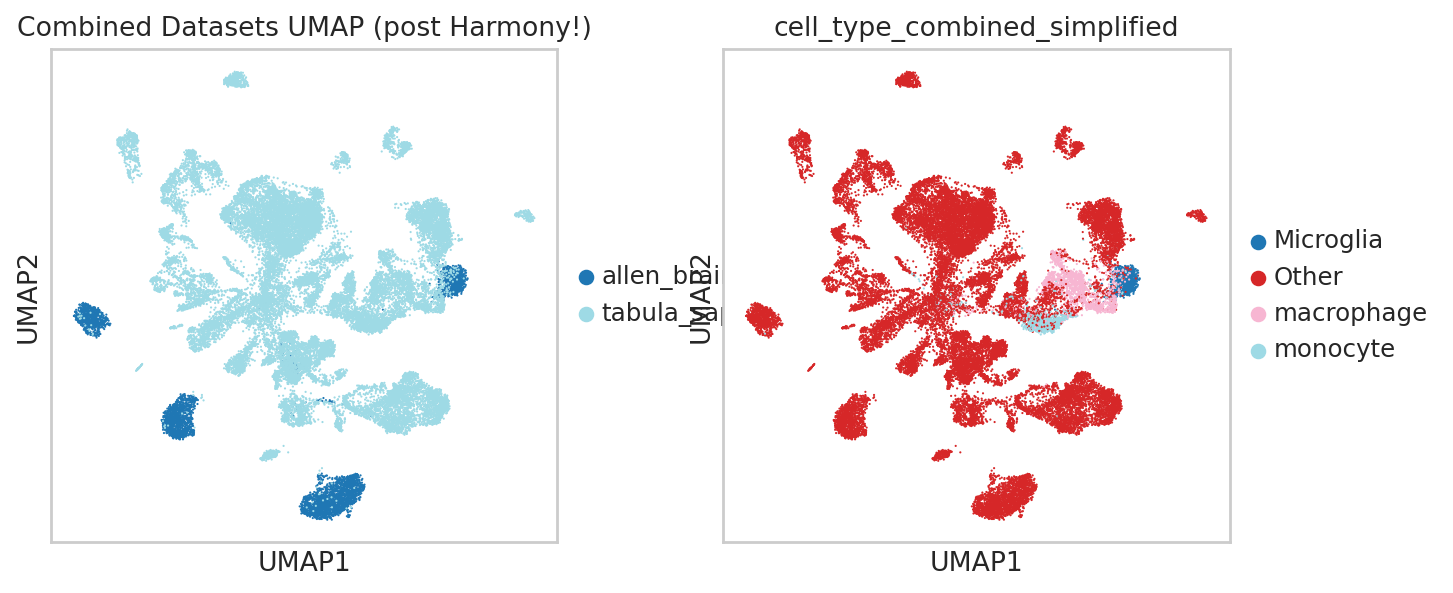

In [16]:
# Visualize with UMAP
sc.pl.umap(
    combined, 
    color=["source", "cell_type_combined_simplified"], 
    title="Combined Datasets UMAP (post Harmony!)",
)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1117: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


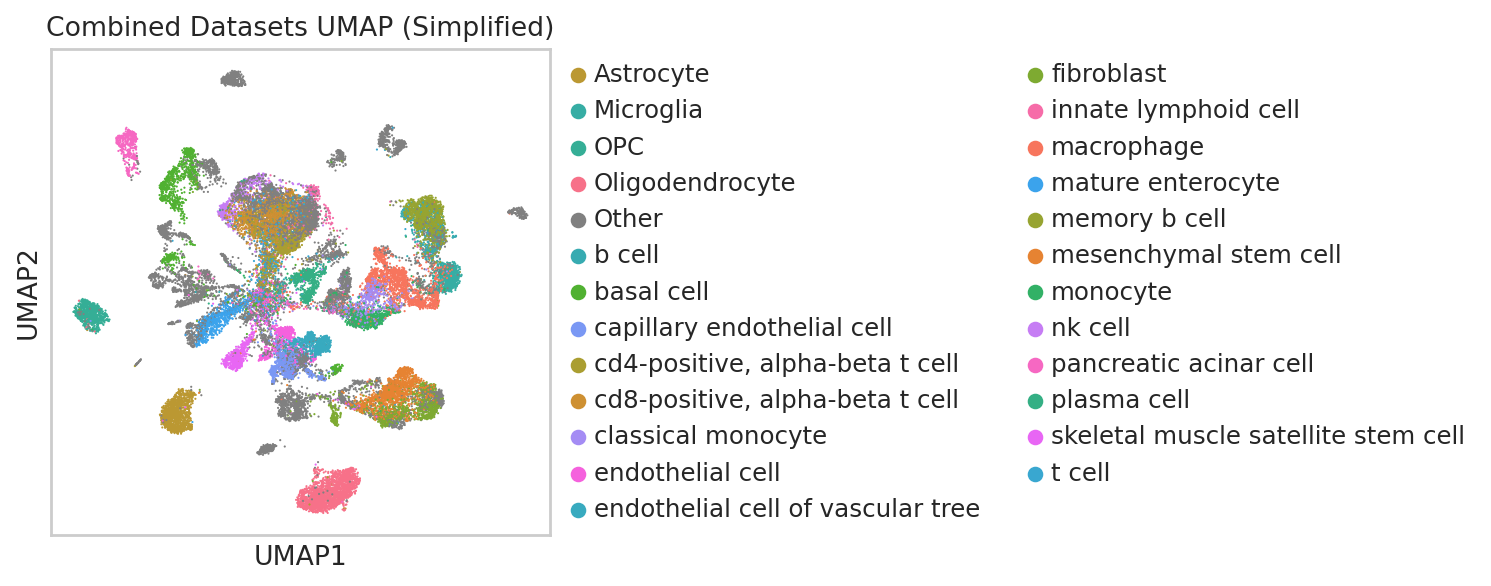

In [20]:
# Get cell type counts and identify cell types with more than 1000 cells
cell_type_counts = combined.obs["cell_type_combined"].value_counts()
cell_types_to_color = cell_type_counts[cell_type_counts >= 500].index.tolist()

# Add a new "simplified" column where infrequent cell types are labeled as "Other"
combined.obs["cell_type_combined_simplified"] = combined.obs["cell_type_combined"].apply(
    lambda x: x if x in cell_types_to_color else "Other"
)

# Convert the new column to a categorical dtype
combined.obs["cell_type_combined_simplified"] = combined.obs["cell_type_combined_simplified"].astype("category")

# Define colors: assign distinct colors to frequent cell types, and use grey for "Other"
cell_type_colors = {
    cell_type: color for cell_type, color in zip(cell_types_to_color, sns.color_palette("husl", len(cell_types_to_color)))
}
cell_type_colors["Other"] = "grey"

# Update `uns` with the colors for visualization
combined.uns["cell_type_combined_simplified_colors"] = [
    cell_type_colors.get(ct, "grey") for ct in combined.obs["cell_type_combined_simplified"].cat.categories
]

# Visualize with UMAP
sc.pl.umap(
    combined, 
    color=["cell_type_combined_simplified"], 
    title="Combined Datasets UMAP (Simplified)",
)


In [21]:
# Define a function to clean up cell type labels
def clean_cell_type(cell_type):
    if "endothelial" in cell_type.lower():
        return "Endothelial"
    elif "b cell" in cell_type.lower():
        return "B cell"
    elif "t cell" in cell_type.lower():
        return "T cell"
    elif "stem" in cell_type.lower():
        return "Stem cell"
    elif "monocyte" in cell_type.lower():
        return "Monocyte"
    else:
        return cell_type  # Keep the original label if no rule matches
    
combined.obs["clean_cell_type"] = combined.obs["cell_type_combined"].apply(clean_cell_type)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1117: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


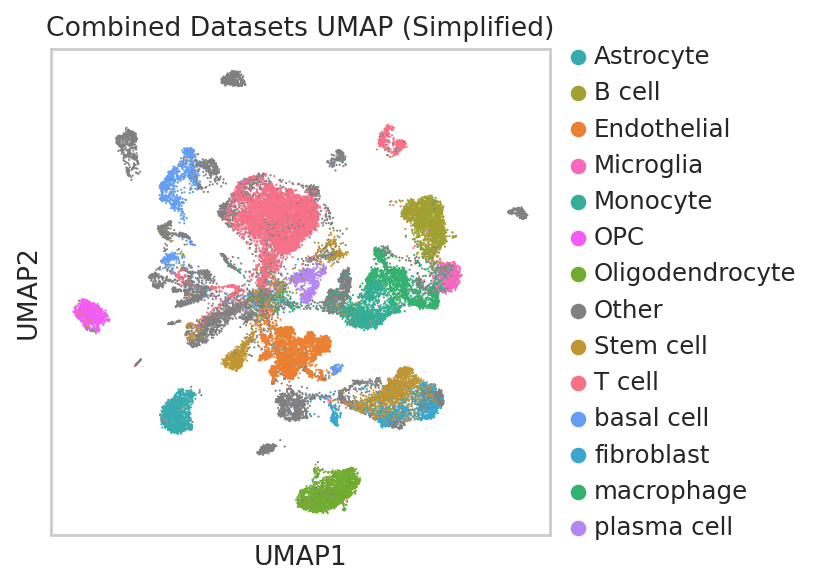

In [24]:
# Get cell type counts and identify cell types with more than 1000 cells
cell_type_counts = combined.obs["clean_cell_type"].value_counts()
cell_types_to_color = cell_type_counts[cell_type_counts >= 750].index.tolist()

# Add a new "simplified" column where infrequent cell types are labeled as "Other"
combined.obs["cell_type_combined_simplified"] = combined.obs["clean_cell_type"].apply(
    lambda x: x if x in cell_types_to_color else "Other"
)

# Convert the new column to a categorical dtype
combined.obs["cell_type_combined_simplified"] = combined.obs["cell_type_combined_simplified"].astype("category")

# Define colors: assign distinct colors to frequent cell types, and use grey for "Other"
cell_type_colors = {
    cell_type: color for cell_type, color in zip(cell_types_to_color, sns.color_palette("husl", len(cell_types_to_color)))
}
cell_type_colors["Other"] = "grey"

# Update `uns` with the colors for visualization
combined.uns["cell_type_combined_simplified_colors"] = [
    cell_type_colors.get(ct, "grey") for ct in combined.obs["cell_type_combined_simplified"].cat.categories
]

# Visualize with UMAP
sc.pl.umap(
    combined, 
    color=["cell_type_combined_simplified"], 
    title="Combined Datasets UMAP (Simplified)",
)


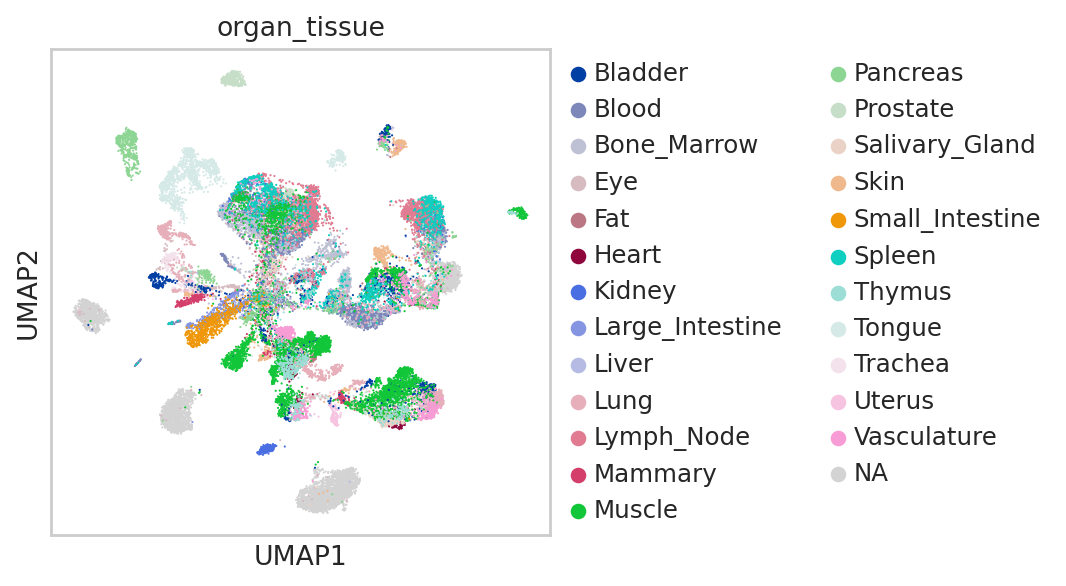

In [46]:
# Visualize with UMAP
sc.pl.umap(
    combined, 
    color=["organ_tissue"])

In [50]:
combined[combined.obs["cell_type_combined_simplified"] == "macrophage"]

View of AnnData object with n_obs × n_vars = 1597 × 28230
    obs: 'exp_component_name', 'specimen_type', 'cluster_color', 'cluster_order', 'cluster_label', 'class_color', 'class_order', 'class_label', 'subclass_color', 'subclass_order', 'subclass_label', 'full_genotype_color', 'full_genotype_order', 'full_genotype_label', 'donor_sex_color', 'donor_sex_order', 'donor_sex_label', 'region_color', 'region_order', 'region_label', 'cortical_layer_color', 'cortical_layer_order', 'cortical_layer_label', 'cell_type_accession_color', 'cell_type_accession_order', 'cell_type_accession_label', 'cell_type_alias_color', 'cell_type_order', 'cell_type_alias_label', 'cell_type_alt_alias_color', 'cell_type_alt_alias_order', 'cell_type_alt_alias_label', 'cell_type_designation_color', 'cell_type_designation_order', 'cell_type_designation_label', 'external_donor_name_color', 'external_donor_name_order', 'external_donor_name_label', 'outlier_call', 'outlier_type', 'n_genes_by_counts', 'log1p_n_genes_by_coun

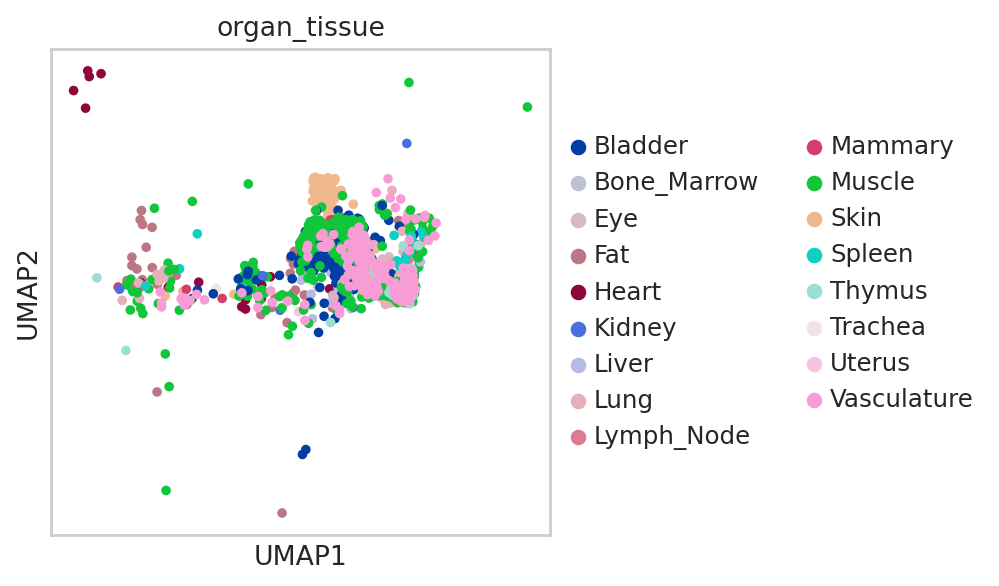

In [49]:
# plot only macrophage cell type on umap
sc.pl.umap(combined[combined.obs["cell_type_combined_simplified"] == "macrophage"], color="organ_tissue")

In [47]:
combined.obs.organ_tissue.value_counts()

organ_tissue
Muscle             5043
Lymph_Node         2384
Bone_Marrow        2290
Spleen             2148
Blood              1977
Lung               1590
Tongue             1391
Bladder            1161
Pancreas            996
Vasculature         847
Skin                844
Salivary_Gland      832
Fat                 651
Prostate            633
Small_Intestine     606
Thymus              599
Mammary             580
Trachea             474
Large_Intestine     442
Eye                 417
Kidney              370
Uterus              286
Heart               277
Liver               213
Name: count, dtype: int64

In [31]:
combined.obs[combined.obs["clean_cell_type"] == "T cell"].dataset.value_counts()

dataset
1    5803
0       0
Name: count, dtype: int64

In [30]:
combined.obs[combined.obs["clean_cell_type"] == "macrophage"].dataset.value_counts()

dataset
1    1597
0       0
Name: count, dtype: int64

In [32]:
# save combined data 
!pwd

/gpfs/commons/home/kisaev/Leaflet-analysis


In [36]:
combined.var

,gene_symbol-0,mt-0,ribo-0,hb-0,n_cells_by_counts-0,mean_counts-0,log1p_mean_counts-0,pct_dropout_by_counts-0,total_counts-0,log1p_total_counts-0,...,feature_type-1,ensemblid-1,mean-1,std-1,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
A1BG,A1BG,False,False,False,13297,8.028634,2.200401,73.092256,396751.0,12.891067,...,Gene Expression,ENSG00000121410.11,0.012076,0.108523,False,NaN,0.014251,0.015776,0.798010,0
A1BG-AS1,A1BG-AS1,False,False,False,1793,0.836413,0.607814,96.371694,41333.0,10.629440,...,Gene Expression,ENSG00000268895.5,0.018003,0.126665,False,NaN,0.009658,0.016769,1.224367,0
A1CF,A1CF,False,False,False,5465,2.904668,1.362173,88.941053,143540.0,11.874376,...,Gene Expression,ENSG00000148584.15,0.024247,0.172158,False,NaN,0.008492,0.010043,1.007823,0
A2M,A2M,False,False,False,22142,86.327782,4.469668,55.193557,4266060.0,15.266201,...,Gene Expression,ENSG00000175899.14,0.307667,0.795199,True,1248.0,0.561251,1.624698,1.757524,2
A2M-AS1,A2M-AS1,False,False,False,1357,2.410567,1.226879,97.253981,119123.0,11.687921,...,Gene Expression,ENSG00000245105.3,0.026221,0.173359,True,2760.0,0.012702,0.024611,1.481845,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,ZXDC,False,False,False,30619,69.565475,4.256541,38.039541,3437717.0,15.050319,...,Gene Expression,ENSG00000070476.15,0.081576,0.263427,False,NaN,0.105593,0.163228,0.954194,0
ZYG11A,ZYG11A,False,False,False,12215,1.040249,0.713072,75.281786,51406.0,10.847529,...,Gene Expression,ENSG00000203995.9,0.001753,0.037978,False,NaN,0.003981,0.004595,0.867127,0
ZYG11B,ZYG11B,False,False,False,42545,105.674828,4.669785,13.906146,5222133.0,15.468416,...,Gene Expression,ENSG00000162378.13,0.159893,0.354727,False,NaN,0.082065,0.122178,0.933497,0
ZYX,ZYX,False,False,False,24628,33.814396,3.550031,50.162899,1671006.0,14.328937,...,Gene Expression,ENSG00000159840.16,0.397226,0.621684,False,NaN,0.169116,0.251027,0.893530,0


In [38]:
if "cell_type_combined_simplified_colors" in combined.uns:
    del combined.uns["cell_type_combined_simplified_colors"]

In [39]:
today = datetime.date.today()
today = today.strftime("%Y-%m-%d")

# save file
combined.write_h5ad(f"/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/TabulaSapien_AllenBrain_combined_nonneuron_adata_{today}.h5ad")